## .dx_process


# data processing for .dx files from benchtop spectrometer

* test software for benchtop nmr
* autophase, autobaseline, zerofilling and line broadening

# Data acquisition
* The data is acquired with a 20 ppm sw to facilitate baseline correction
* The center frequency is set to 5 ppm
* The data should be acquired with a manually set reciever gain.  We found a value of 14 for RG by manually running a typical sample in DMAC.  The data is distorted and difficult to phase if RG is set too high. 

# Notes
* change system path for your computer
* first point correction not helpful
* linear prediction of initial points does not lead to improvement
* a Hanning filter is used to ensure that the FID is smoothly truncated to zero for better phasing
* use native nmrglue for autophase
* Parameters for automatic baseline correction have been implemented
* The x axis from the spectrometer is unreliable.  The x axis is set using using chemical shift from solvent peak
* accurate peak intergals with adjustable widths and localized baseline subtraction

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import sys
import os
# nmrglue directory
#pydir1=r'C:\Users\baldwila\Documents\baldwin_subgroup\UNC_FlowChem_TransientNMR\NMR_data\LAB_24_002'.. if you locally have a nmrglue package
#sys.path.append(pydir1)
# nmrglue v0.9
import nmrglue as ng
import pandas as pd

from tkinter import filedialog
from tkinter import *

# import pickle
import copy
from scipy import optimize

import warnings
warnings.filterwarnings("ignore")

# %matplotlib nbagg
%matplotlib inline

In [2]:
!pip show numpy

Name: numpy
Version: 1.21.5
Summary: NumPy is the fundamental package for array computing with Python.
Home-page: https://www.numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: BSD
Location: c:\users\baldwila\anaconda3\envs\nmr_process\lib\site-packages
Requires: 
Required-by: contourpy, matplotlib, nmrglue, pandas, scipy


In [3]:
""" functions """

def getfndir():
    """ get directory name """
    root = Tk()
    root.withdraw()
    msg1='Choose data directory: '
    print(msg1)
    fndir=filedialog.askdirectory()
    print(fndir)
    return fndir

def read_dx_60MHz(fn):
    """ read .dx data format 
    return: dic, data udic """
    dic, data = ng.fileio.jcampdx.read(fn)
    udic = ng.fileio.jcampdx.guess_udic(dic, data)
    
    """ create complex array for FT """
    tdata=np.array(data)
    tdata=tdata[0,:] + 1.0j*tdata[1,:]
    
    """ fix parameters """
    offset = dic['.SOLVENTREFERENCE']
    offset = float(offset[0])
    sw = dic['$SW']
    sw = float(sw[0])*udic[0]['obs']
    udic[0]['sw'] = sw
    udic[0]['offset'] = offset
    
    return dic, tdata, udic


""" automatic baseline detection"""
def abd(data, nsec, nf, nwin):
    # auto baseline detection
    # input: data, nsec (# baseline sections (32))
    #   nf (noise factor (3), nwin: window width (20))
    # output: xbsl, ybsl
    ndata=int(data.shape[0]/nsec)
    npts=data.shape[0]
    sigma=np.zeros(nsec)
    yt=np.zeros(npts)
    for i in range(nsec):
            tdata=data[i*ndata:(i+1)*ndata]
            sigma[i]=np.max(tdata)-np.min(tdata)
    nl=np.min(sigma)               # noise level
    # find baseline points
    for i in range(nwin+1, npts-(nwin+1), 1):
        tdata=data[int(i-nwin/2):int(i+nwin/2)]
        tsigma=np.max(tdata)-np.min(tdata)
        if tsigma < nl*nf:
            yt[i]=data[i]
    # --- get xbsl and ybsl 
    xbsl=np.array([])
    ybsl=np.array([])
    for i in range(npts):
        if yt[i] != 0.:
            xbsl=np.append(xbsl, i)
            ybsl=np.append(ybsl, yt[i])
    return xbsl, ybsl

""" polynomial fit to baseline """
def bsl_poly(data, xbsl, ybsl, porder):
    """ xbsl - x baseline point
        ybsl - y baseline point
        porder polynomial order for fit
        return: baseline corrected data"""
    npt = data.shape[-1]
    xpts=np.linspace(1,npt,npt)
    z = np.polyfit(xbsl, ybsl, porder)
    f = np.poly1d(z)
    bsl = f(xpts)
    return data-bsl

def ppm_to_pts(xax, xe):
    """ convert ppm list to list of points """
    npts = len(xe)
    xe_pts = []
    for i in range(npts):
        indx=np.argmin(np.abs(xax-xe[i]))
        xe_pts.append(indx)
    return xe_pts
    
def get_xax(data, udic):
    """ create corrected axis from udic """
    npts = len(data)
    left_pt = udic[0]['offset'] + udic[0]['sw']/(2.*udic[0]['obs'])
    right_pt = udic[0]['offset'] - udic[0]['sw']/(2.*udic[0]['obs'])

    xax = np.linspace(right_pt, left_pt, npts)
    return xax

def xax_fix(xax, tdata, ref_ppm):
    th = 0.8*np.max(tdata.real)
    peaks = ng.peakpick.pick(tdata, th)
    xpeak = peaks['X_AXIS'].astype('int')
    xppm=xax[xpeak]
    delta = ref_ppm -np.min(xppm)
    xax = xax + delta
    return xax

def pickplot(ax1, tdata, th):
    peaks = ng.peakpick.pick(tdata, th)
    xpeak = peaks['X_AXIS'].astype('int')
    xppm=ax1[xpeak]
    toff=0.01*max(tdata)
    # --- plots
    plt.plot(ax1, tdata)
    plt.plot(ax1[xpeak], tdata[xpeak]+toff, 'r|')
    ax1[xpeak]
    return peaks, xpeak

## get files from directory

In [4]:
""" set directory """
dirproj = getfndir()

""" get data file names """
path=dirproj
fnamef = os.listdir(path)

""" select files of interest (foi) for analysis"""
foi = 'pm'
file_list = []
nfiles = len(fnamef)

for i in range(nfiles):
    """ select files of interest """
    # if foi in fnamef[i]:
    file_list.append(fnamef[i])
file_list[0:5]

Choose data directory: 
C:/Users/baldwila/Documents/baldwin_subgroup/UNC_FlowChem_TransientNMR/NMR_data/LAB_24_002_shortened_test


['experiment_data_1724776081.051232.dx',
 'experiment_data_1724776125.795736.dx',
 'experiment_data_1724776170.261733.dx',
 'experiment_data_1724776214.485911.dx',
 'experiment_data_1724776258.877871.dx']

In [ ]:
# fnamef

Optimization terminated successfully.
         Current function value: 0.000067
         Iterations: 62
         Function evaluations: 116


Text(0.5, 1.0, 'experiment_data_1724776081.051232.dx')

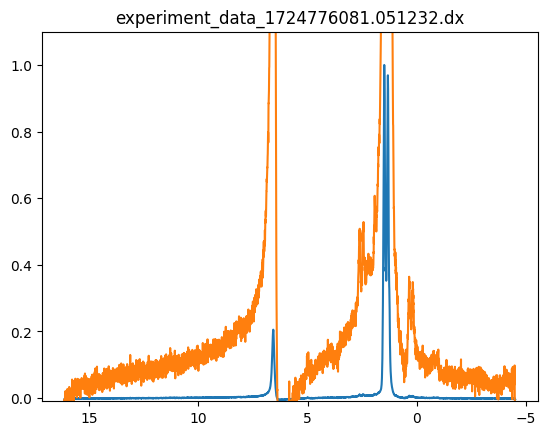

In [5]:
""" NMR data processing  """
i=1
fn = file_list[0]

""" set parameters for data processing """

# todo -- create pulldown menu with parameter choices for lb_hz and solvent

dicproc ={}

# set line broadening
dicproc['lb'] = 2.0

# set solvent 
dicproc['solvent'] = 'DMF'

""" function to process .dx files """
def proc_dx(fn, dicproc): 
    fn1=os.path.join(path, fn)
    dic, data, udic = read_dx_60MHz(fn1)

    xax = get_xax(data, udic)
    tdata = copy.deepcopy(data)


    """ window function multiplication """
    npt=tdata.shape[0]
    xpt=np.linspace(1,npt,npt)
    win = 0.5 + 0.5*np.cos(np.pi*xpt/npt)
    tdata = tdata*win

    """ line broadenting """
    lb_hz = dicproc['lb']
    lb_pts=lb_hz/udic[0]['sw']
    tdata = ng.proc_base.em(tdata, lb_pts)

    """ fft """
    tdata = ng.proc_base.fft(data) 

    """ auto phase  """
    tdata = ng.proc_autophase.autops(tdata, "peak_minima") 

    """ baseline correction """
    # auto baseline detection -- parameters altered for benchtop NMR
    xbsl, ybsl = abd(tdata, 128, 3, 60)
    tdata = bsl_poly(tdata, xbsl, ybsl, 1)
    
    """ fix x axis """
    scf = np.max(tdata.real)
    tdata = tdata/scf
    # set peak pick threshold to 0.9 for tallest peaks
    th = 0.9
    peaks = ng.peakpick.pick(tdata, th)
    xpeak = peaks['X_AXIS'].astype('int')
    
    # todo -- set up for other solvents
    if dicproc['solvent'] == 'DMF':
        ref_ppm = 1.33
        
    # todo -- make sure solvent reference peak is first in list
    delx = xax[xpeak[0]] - ref_ppm
    xax = xax - delx
    
    return xax, tdata

xax, tdata = proc_dx(fn, dicproc)
# plot
fig, ax = plt.subplots()
plt.plot(xax, tdata.real)
plt.plot(xax, tdata.real*40 +.1)
plt.ylim(-.01, 1.1)
plt.gca().invert_xaxis()
plt.title(fn)

In [5]:
# i=1
# fn = file_list[2]
# fn

In [6]:
# fn1=os.path.join(path, fn)
# dic, data = ng.fileio.jcampdx.read(fn1)
# udic = ng.fileio.jcampdx.guess_udic(dic, data)

# data.shape

# Notes
The autophasing and auto baseline correction works to the 99% level.  The small differences can be corrected by localized baseline subtraction.

A line broadening larger than 2 Hz may be appropriate for polymer samples to increase the signal-to-noise

In [7]:
# """  integration with constant width """

# def peakplot(ax, data, x1, x2):
#     idx1 = (np.abs(ax-x1)).argmin()
#     idx2 = (np.abs(ax-x2)).argmin()
#     x=ax[idx1:idx2]
#     y=data[idx1:idx2]
#     plt.fill_between(x, y, y[0], color='r', alpha=0.25)
#     plt.plot(x[0], y[0], 'ro')
#     plt.plot(x[-1], y[-1], 'ro')

# # plot data of interest 
# fig, ax = plt.subplots()
# plt.plot(xax, tdata)
# plt.gca().invert_xaxis()
# plt.xlim(10, 3.5)
# plt.ylim(-.01, .1)

# # plot integration area

# xpk = [4.84, 4.21]
# int_width = .5
# npks = len(xpk)
# for i in range(npks):
#     peakplot(xax, tdata, xpk[i] - int_width, xpk[i] + int_width)
    
# plt.title('Integration with constant width')

## Local Baseline Inegration


The red areas in the above plot show integrated areas for peaks that differ in width and intensity.  This is particularly challenging for polymers with a sharp integration standard (6.1 ppm).  The plot also illustrates the challenges in integrating peaks that are low in intensity relative to the solvent, that small imperfections in the baseline and the residual tail of the much larger solvent peak can affect the integration.

One solution is to use a dictionary containing the peak frequency and width and to subtract the local baseline.  The local baseline is the baseline calculated for the begining and end of the integration area.

In [8]:
# """ set integration peaks and widths on a typical spectrum"""

# # todo -- create interactive tool to identify peaks of interest and widths
# # todo -- create a dictionary of peaks and widths

# # plot data of interest 
# fig, ax = plt.subplots()
# plt.plot(xax, tdata)
# plt.gca().invert_xaxis()
# plt.xlim(10, 3.5)
# plt.ylim(-.001, .005)

# # plot integration area

# xpk = [9.5, 8.4, 7.0, 6.1, 5.0, 4.12 ]
# int_width = [.3, .4, .5, .12, .3, .1]
# npks = len(xpk)
# for i in range(npks):
#     peakplot(xax, tdata, xpk[i] - int_width[i], xpk[i] + int_width[i])
    
# plt.title('Integration with variable width')

## Adjustable width integration

The integration can be improved by setting the width for each peak, but there are still problems due to the small size of the peaks compared to the residual peak from the solvent that affects the baselines.

Text(0.5, 1.0, 'Integration with variable width and baseline subtraction')

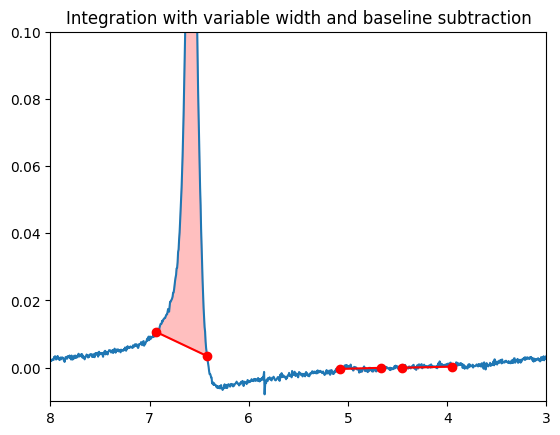

In [52]:
""" integration with variable width and local baseline subtraction """

def peak_plot_lbs(ax, data, x1, x2):
    """ peak plot with local baseline subtraction """
    idx1 = (np.abs(ax-x1)).argmin()
    idx2 = (np.abs(ax-x2)).argmin()
    x=ax[idx1:idx2]
    y=data[idx1:idx2]
    
    """ linear baseline """
    npts = len(x)
    x0, x1 = x[0], x[-1]
    y0, y1 = y[0], y[-1]
    dx = x0 - x1
    dy = y0 - y1
    slope_bsl = dy/npts
    xbsl = np.linspace(0, npts, npts)
    ybsl = y[0] - xbsl*slope_bsl
    plt.fill_between(x, y, ybsl, color='r', alpha=0.25)
    plt.plot(x, ybsl, 'r-')
    plt.plot(x0, y0, 'ro')
    plt.plot(x1, y1, 'ro')
    
# plot data of interest 
fig, ax = plt.subplots()
plt.plot(xax, tdata)
plt.gca().invert_xaxis()
plt.xlim(8, 3)
plt.ylim(-.01, .1)

# plot integration area

xpk = [6.68, 4.88, 4.21]
int_width = [0.26, .21, .255]
npks = len(xpk)
for i in range(npks):
    peak_plot_lbs(xax, tdata, xpk[i] - int_width[i], xpk[i] + int_width[i])
    
plt.title('Integration with variable width and baseline subtraction')

## Integration with local baseline subtraction

A more accurate estimate of the intensity can be obtained by subtracting the local baseline which is calculated as a linear baseline (with slope) over the width of the peak.

Optimization terminated successfully.
         Current function value: 0.000015
         Iterations: 64
         Function evaluations: 117
Optimization terminated successfully.
         Current function value: 0.000213
         Iterations: 59
         Function evaluations: 110
Optimization terminated successfully.
         Current function value: 0.000034
         Iterations: 62
         Function evaluations: 117
Optimization terminated successfully.
         Current function value: 0.000124
         Iterations: 60
         Function evaluations: 112
Optimization terminated successfully.
         Current function value: 0.000029
         Iterations: 64
         Function evaluations: 118
Optimization terminated successfully.
         Current function value: 0.000032
         Iterations: 64
         Function evaluations: 118
Optimization terminated successfully.
         Current function value: 0.000051
         Iterations: 64
         Function evaluations: 116


(-0.01, 0.1)

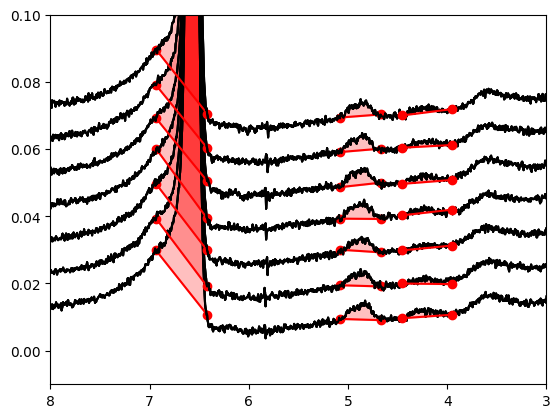

In [55]:
""" overplot of all integrated data files """

nfiles = len(file_list)
offset = 0.01

# todo -- store the x axis, spectra and parameters in a dictionary

fig, ax = plt.subplots()

for j in range(1,8):
    fn = file_list[-j]
    xax, tdata = proc_dx(fn, dicproc)
    tdata = tdata + offset*j
    for i in range(npks):
        plt.plot(xax, tdata, 'k-')
        peak_plot_lbs(xax, tdata, xpk[i] - int_width[i], xpk[i] + int_width[i])

        
plt.gca().invert_xaxis()
plt.xlim(8, 3)
plt.ylim(-.01, 0.1)

# plot
# figdir = os.getcwd() + '\\figs'
# fnplt='JD2-63_polymer_Rxn_integration.240604.png'
# fntemp=os.path.join(figdir,fnplt)
# plt.savefig(fntemp, dpi=300,bbox_inches='tight' )

In [11]:
# file_list
for j in range(1,8):
    fn = file_list[-j]
    print(fn)

experiment_data_1724784423.735419.dx
experiment_data_1724784379.830326.dx
experiment_data_1724784335.942544.dx
experiment_data_1724784292.068296.dx
experiment_data_1724784248.191106.dx
experiment_data_1724784203.389067.dx
experiment_data_1724784159.41518.dx


## Notes

This plot shows the results from five experiments.  Using local baseline subtraction, the intergals are calculated from the colored areas.

In [56]:
""" integrate the spectra and store in Pandas dataframe """

def integrate_lbs(ax, data, x1, x2):
    """ returns peak intergals with local baseline subtraction """
    
    """ extract area for integration """
    idx1 = (np.abs(ax-x1)).argmin()
    idx2 = (np.abs(ax-x2)).argmin()
    x=ax[idx1:idx2]
    y=data.real[idx1:idx2]
    
    """ linear baseline """
    npts = len(x)
    x0, x1 = x[0], x[-1]
    y0, y1 = y[0], y[-1]
    dx = x0 - x1
    dy = y0 - y1
    slope_bsl = dy/npts
    xbsl = np.linspace(0, npts, npts)
    ybsl = y[0] - xbsl*slope_bsl
    
    """ subtraction local baseline """
    yint = np.sum(y.real - ybsl)
    return yint

""" col names for df """
nxpk = len(xpk)
cols = ['Files']
for i in range(nxpk):
    str1 = str(xpk[i])
    cols.append(str1)
    
""" create dataframe """
df=pd.DataFrame(columns = cols)

dic_int = {}

for j in range(nfiles):
    
    """ read/process files """
    fn = file_list[j]
    xax, tdata = proc_dx(fn, dicproc)
    
    """ integrate files """
    int_list = []
    for i in range(npks):
        yint = integrate_lbs(xax, tdata, xpk[i] - int_width[i], xpk[i] + int_width[i])
        int_list.append(yint)
        

    """ store list in dataframe """
    new_row = {'Files': fn}
    # list intergals in dictionary
    for i in range(nxpk):
        new_row.update({cols[i+1]: int_list[i]})
    df=df.append(new_row, ignore_index=True)

#df.to_csv(C:\Users\baldwila\Documents\baldwin_subgroup\Transient_NMR_processed_dx_files\test.csv', index=False)

Optimization terminated successfully.
         Current function value: 0.000067
         Iterations: 62
         Function evaluations: 116
Optimization terminated successfully.
         Current function value: 0.000088
         Iterations: 61
         Function evaluations: 117
Optimization terminated successfully.
         Current function value: 0.000377
         Iterations: 61
         Function evaluations: 114
Optimization terminated successfully.
         Current function value: 0.000049
         Iterations: 62
         Function evaluations: 120
Optimization terminated successfully.
         Current function value: 0.000057
         Iterations: 64
         Function evaluations: 118
Optimization terminated successfully.
         Current function value: 0.000047
         Iterations: 64
         Function evaluations: 121
Optimization terminated successfully.
         Current function value: 0.000082
         Iterations: 63
         Function evaluations: 119
Optimization terminated suc

In [57]:
df.to_csv('C:/Users/baldwila/Documents/baldwin_subgroup/Transient_NMR_processed_dx_files/LAB_24_002_shortened.csv', index=False)

# Notes

The intensity of the reference peak at 6.1 ppm should be the same if the spectra were gathered using the same acquisition and processing parameters.  The variation is one measure of the uncertainty.

In [ ]:
""" integrate the spectra, normalize to reference intensity, and store in Pandas dataframe """

""" create dataframe """
df=pd.DataFrame(columns = cols)

dic_int = {}

""" set intensity reference """
dicproc['int_ref'] = 3.0
dicproc['int_ref_ppm'] = 6.1

for j in range(nfiles):
    
    """ read/process files """
    fn = file_list[j]
    xax, tdata = proc_dx(fn, dicproc)
    
    """ integrate files """
    int_list = []
    for i in range(npks):
        yint = integrate_lbs(xax, tdata, xpk[i] - int_width[i], xpk[i] + int_width[i])
        int_list.append(yint)
        
    """ scale intensity to reference peak """
    int_ref = dicproc['int_ref']
    int_ref_ppm = dicproc['int_ref_ppm']
    indx = xpk.index(int_ref_ppm)
    # calculate scale factor
    scf = int_ref/int_list[indx]
    int_list = scf*np.array(int_list)
    
    """ store list in dataframe """
    new_row = {'Files': fn}
    # list intergals in dictionary
    for i in range(nxpk):
        new_row.update({cols[i+1]: int_list[i]})
    df=df.append(new_row, ignore_index=True)

    


df